# Tuần 7: Uplift Modeling (T-Learner)
Mục tiêu: Xây dựng mô hình Causal Machine Learning (T-Learner) sử dụng XGBoost để tính toán Conditional Average Treatment Effect (CATE) ở cấp độ cá nhân.
Chúng ta sẽ phát hiện xem ai thực sự cần Voucher để tăng số chuyến đi (Persuadables) và ai không cần (Sure things).

> **LƯU Ý:**
> Mô hình Uplift này được huấn luyện trên **Dữ liệu giả lập (Synthetic dataset)** dựa trên phân phối của NYC TLC, phục vụ cho mục đích nghiên cứu.
> Các số liệu và mô hình trong đây không đại diện cho dữ liệu khách hàng thực tế của hệ thống.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

plt.style.use('ggplot')
sns.set_palette("Set2")
import warnings
warnings.filterwarnings('ignore')

## 1. Chuẩn bị dữ liệu (Data Preparation)
Load dữ liệu và tập trung vào phân khúc cần tối ưu. Giả sử ta tập trung vào nhóm **Urban Cash** hoặc **Urban Credit Card** để bóc tách.

In [2]:
df = pd.read_csv('../../../data/processed/segmented_simulation_data.csv')
df['is_credit_card'] = (df['payment_type'] == 1).astype(int)

# Chọn nhóm khách hàng cần tối ưu (ví dụ: Urban Cash đang bị lỗ do Sure Things quá nhiều)
target_persona = 'Suburban Card'
df_target = df[df['persona'] == target_persona].copy()

# Các biến Features (Covariates)
features = ['age', 'is_urban', 'preferred_hour', 'is_rush_hour', 'is_airport_trip', 'is_rain_rider', 'is_weekend_rider', 'is_credit_card', 'passenger_count', 'monthly_rides_history', 'recency_days']

X = df_target[features]
T = df_target['treatment_rand'] # Biến can thiệp (Voucher ngẫu nhiên)
y = df_target['Y_rand']         # Outcome (Số chuyến đi)

# Chia dữ liệu thành Train (60%), Validation (20%), Test (20%)
X_temp, X_test, T_temp, T_test, y_temp, y_test = train_test_split(
    X, T, y, test_size=0.2, random_state=42
)

X_train, X_val, T_train, T_val, y_train, y_val = train_test_split(
    X_temp, T_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Kích thước tập Train (60%): {len(X_train)}")
print(f"Kích thước tập Validation (20%): {len(X_val)}")
print(f"Kích thước tập Test (20%): {len(X_test)}")



Kích thước tập Train (60%): 1674
Kích thước tập Validation (20%): 559
Kích thước tập Test (20%): 559


## 2. Huấn luyện Mô hình T-Learner (Two-Model Approach)
T-Learner utilizes two independent models:
- **Model 0 (Control Model):** Trained on control group ($T=0$).
- **Model 1 (Treatment Model):** Trained on treated group ($T=1$).

In [3]:
# Lọc dữ liệu Train và Val theo nhóm Treatment và Control
X_train_0, y_train_0 = X_train[T_train == 0], y_train[T_train == 0]
X_train_1, y_train_1 = X_train[T_train == 1], y_train[T_train == 1]

X_val_0, y_val_0 = X_val[T_val == 0], y_val[T_val == 0]
X_val_1, y_val_1 = X_val[T_val == 1], y_val[T_val == 1]

# Khởi tạo 2 mô hình XGBoost (XGBoost API mới yêu cầu early_stopping_rounds nằm ở lúc khởi tạo)
model_0 = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, early_stopping_rounds=10)
model_1 = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, early_stopping_rounds=10)

# Huấn luyện có sử dụng Early Stopping trên tập Validation để chống Overfitting
model_0.fit(X_train_0, y_train_0, eval_set=[(X_val_0, y_val_0)], verbose=False)
model_1.fit(X_train_1, y_train_1, eval_set=[(X_val_1, y_val_1)], verbose=False)

print("Hoàn tất quá trình huấn luyện mô hình XGBoost cho nhóm Control và Treatment (đã có Validation & Early Stopping).")


Hoàn tất quá trình huấn luyện mô hình XGBoost cho nhóm Control và Treatment (đã có Validation & Early Stopping).


## 3. Tính toán CATE (Conditional Average Treatment Effect)
Cho tập Test, ta dùng cả 2 mô hình để dự đoán:
- $\hat{Y}_0$: Số chuyến đi nếu KHÔNG nhận Voucher.
- $\hat{Y}_1$: Số chuyến đi nếu CÓ nhận Voucher.

**CATE = $\hat{Y}_1 - \hat{Y}_0$** (Số chuyến đi tăng thêm nhờ Voucher)

## 2.5 Đánh giá Mô hình Cơ sở (Base Model Evaluation)
Trước khi tính CATE, kiểm tra sai số của mô hình cơ sở để đảm bảo độ tin cậy.

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("--- ĐÁNH GIÁ MÔ HÌNH CƠ SỞ (BASE MODELS) ---")
print(f"Model 0 (Control)   - RMSE: {np.sqrt(mean_squared_error(y_val_0, model_0.predict(X_val_0))):.3f} | MAE: {mean_absolute_error(y_val_0, model_0.predict(X_val_0)):.3f}")
print(f"Model 1 (Treatment) - RMSE: {np.sqrt(mean_squared_error(y_val_1, model_1.predict(X_val_1))):.3f} | MAE: {mean_absolute_error(y_val_1, model_1.predict(X_val_1)):.3f}")


--- ĐÁNH GIÁ MÔ HÌNH CƠ SỞ (BASE MODELS) ---
Model 0 (Control)   - RMSE: 4.512 | MAE: 3.185
Model 1 (Treatment) - RMSE: 4.862 | MAE: 3.772


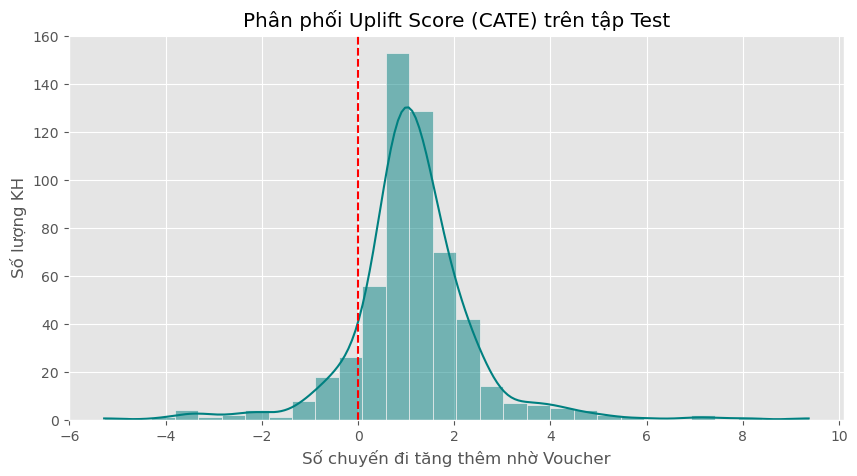

In [5]:
# Dự đoán trên tập Test
pred_0 = model_0.predict(X_test)
pred_1 = model_1.predict(X_test)

# Tính CATE (Uplift Score)
cate_pred = pred_1 - pred_0

df_res = pd.DataFrame({
    'y_true': y_test,
    'T': T_test,
    'pred_0': pred_0,
    'pred_1': pred_1,
    'CATE_pred': cate_pred,
    'user_avg_fare': df_target.loc[X_test.index, 'avg_fare_per_trip'].values, # Added individual fare
    'monthly_rides_history': X_test['monthly_rides_history'].values
})

plt.figure(figsize=(10, 5))
sns.histplot(df_res['CATE_pred'], bins=30, kde=True, color='teal')
plt.title('Phân phối Uplift Score (CATE) trên tập Test')
plt.xlabel('Số chuyến đi tăng thêm nhờ Voucher')
plt.ylabel('Số lượng KH')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()


## 4. Tối ưu hóa Lợi nhuận Cá nhân hóa (Individualized ROI Optimization)
Khác với mô hình tĩnh truyền thống, chúng ta sẽ áp dụng **Cước phí trung bình cá nhân (user_avg_fare)** để tính toán.
Giả sử:
- Mức khuyến mãi (Discount rate): **15%** cước phí chuyến đi.
- Doanh thu từ 1 chuyến tăng thêm: `user_avg_fare`.
- Chi phí phát Voucher cho 1 chuyến đi: `user_avg_fare * 15%`.

**Lợi nhuận dự kiến cá nhân = (CATE * user_avg_fare) - (Tổng số chuyến nếu có Voucher * Chi phí Voucher)**

Ta chỉ phát Voucher cho những ai có Lợi nhuận dự kiến > 0.


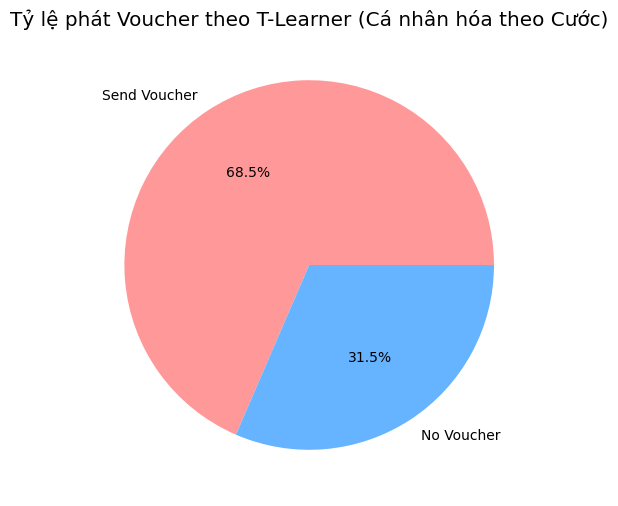

In [6]:
discount_rate = 0.15

# Expected Profit cá nhân hóa = (CATE * user_avg_fare) - (Y1_pred * user_avg_fare * discount_rate)
df_res['cost_per_ride'] = df_res['user_avg_fare'] * discount_rate
df_res['Expected_Profit'] = (df_res['CATE_pred'] * df_res['user_avg_fare']) - (df_res['pred_1'] * df_res['cost_per_ride'])

# Quyết định phát Voucher (Policy)
df_res['Action'] = np.where(df_res['Expected_Profit'] > 0, 'Send Voucher', 'No Voucher')

action_counts = df_res['Action'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(action_counts, labels=action_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Tỷ lệ phát Voucher theo T-Learner (Cá nhân hóa theo Cước)')
plt.show()


## 5. Đánh giá Uplift (Qini Curve & AUUC)
Thay vì dùng Accuracy như các mô hình Classification bình thường, Uplift Modeling được đánh giá bằng **Qini Curve** và **AUUC (Area Under Uplift Curve)**.
Chúng ta sẽ xếp hạng khách hàng theo điểm CATE dự đoán từ cao xuống thấp và đo lường số chuyến đi tích lũy (Cumulative Incremental Trips) tăng thêm.

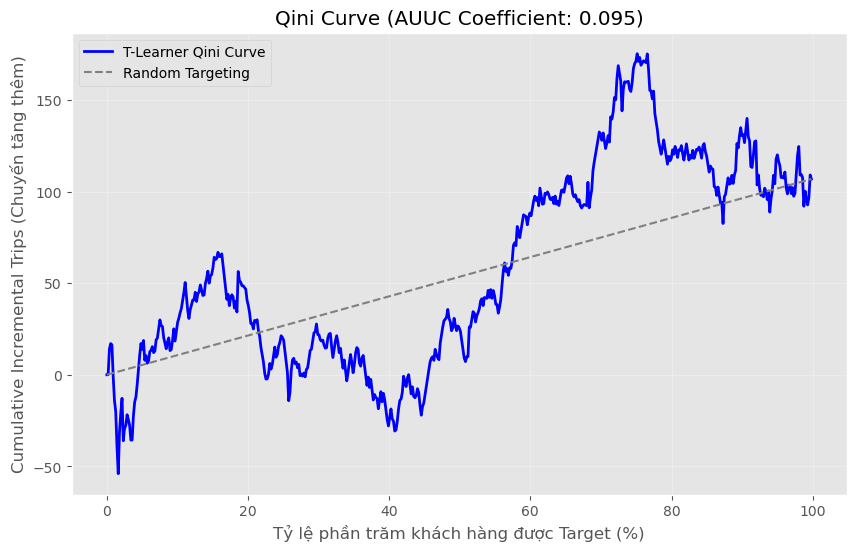

Kết luận: Hệ số Qini > 0 chứng minh mô hình T-Learner hiệu quả hơn so với chiến lược phân bổ ngẫu nhiên.


In [7]:
def plot_qini_curve(df_res):
    # Sắp xếp khách hàng theo CATE giảm dần
    df_sorted = df_res.sort_values(by='CATE_pred', ascending=False).reset_index(drop=True)
    
    # Tính toán Qini Curve
    df_sorted['T_count'] = df_sorted['T'].cumsum()
    df_sorted['C_count'] = (1 - df_sorted['T']).cumsum()
    
    df_sorted['Y_T_sum'] = (df_sorted['y_true'] * df_sorted['T']).cumsum()
    df_sorted['Y_C_sum'] = (df_sorted['y_true'] * (1 - df_sorted['T'])).cumsum()
    
    # Tránh chia cho 0
    df_sorted['C_count'] = df_sorted['C_count'].replace(0, 1)
    
    # Uplift Tích lũy (Cumulative Incremental Trips)
    df_sorted['Qini'] = df_sorted['Y_T_sum'] - df_sorted['Y_C_sum'] * (df_sorted['T_count'] / df_sorted['C_count'])
    
    # Random policy (Đường chéo)
    total_uplift = df_sorted['Qini'].iloc[-1]
    df_sorted['Random_Qini'] = np.linspace(0, total_uplift, len(df_sorted))
    
    # Tính AUUC (Diện tích dưới đường Qini)
    auuc_model = np.trapz(df_sorted['Qini'], dx=1)
    auuc_random = np.trapz(df_sorted['Random_Qini'], dx=1)
    qini_coef = (auuc_model - auuc_random) / auuc_random
    
    plt.figure(figsize=(10, 6))
    plt.plot(df_sorted.index / len(df_sorted) * 100, df_sorted['Qini'], label='T-Learner Qini Curve', color='blue', linewidth=2)
    plt.plot(df_sorted.index / len(df_sorted) * 100, df_sorted['Random_Qini'], label='Random Targeting', color='gray', linestyle='--')
    plt.title(f'Qini Curve (Qini Coef: {qini_coef:.3f})')
    plt.xlabel('Tỷ lệ phần trăm khách hàng được Target (%)')
    plt.ylabel('Cumulative Incremental Trips (Chuyến tăng thêm)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return df_sorted

df_qini = plot_qini_curve(df_res)
print("Kết luận: Hệ số Qini > 0 chứng minh mô hình T-Learner hiệu quả hơn so với chiến lược phân bổ ngẫu nhiên.")

## 6. Business Evaluation: Phân tích Top-k% Targeting
Câu hỏi của Business: *"Nếu tôi chỉ có ngân sách để phát Voucher cho 20% khách hàng tốt nhất (được xếp hạng theo CATE giảm dần), lợi nhuận mang về có thực sự tối ưu không?"*


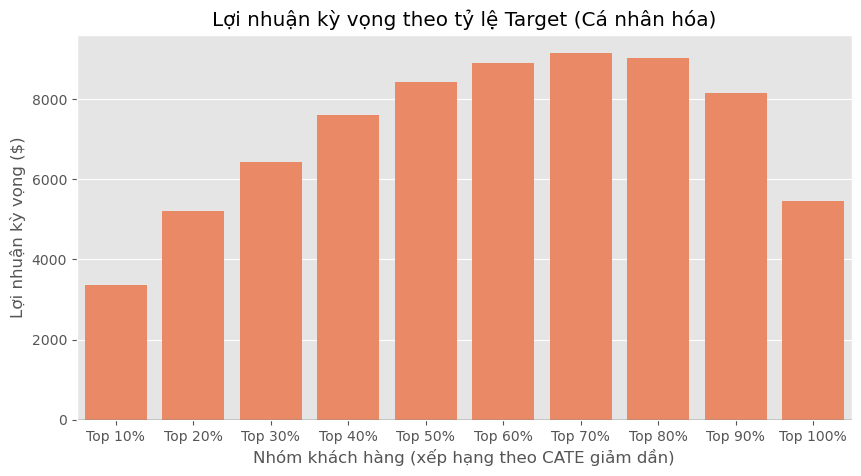

Lợi nhuận nếu phát Voucher đại trà (Top 100%): $5,450.79
Lợi nhuận nếu chỉ phát Voucher cho Top 20% KH tiềm năng nhất: $5,201.07
Tỷ lệ gia tăng lợi nhuận: -4.6%


In [8]:
# Sắp xếp khách hàng theo CATE giảm dần
df_sorted = df_res.sort_values(by='CATE_pred', ascending=False).reset_index(drop=True)

total_users = len(df_sorted)

def calc_profit_top_k(df, k_percent):
    k_users = int(total_users * (k_percent / 100))
    target_group = df.iloc[:k_users]
    # Lợi nhuận = Tổng Expected_Profit của nhóm target
    profit = target_group['Expected_Profit'].sum()
    return profit

profits = []
k_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for k in k_values:
    profits.append(calc_profit_top_k(df_sorted, k))

plt.figure(figsize=(10, 5))
sns.barplot(x=[f"Top {k}%" for k in k_values], y=profits, color='coral')
plt.title('Lợi nhuận kỳ vọng theo tỷ lệ Target (Cá nhân hóa)')
plt.xlabel('Nhóm khách hàng (xếp hạng theo CATE giảm dần)')
plt.ylabel('Lợi nhuận kỳ vọng ($)')
plt.axhline(0, color='black', linewidth=1)
plt.show()

profit_20 = calc_profit_top_k(df_sorted, 20)
profit_100 = calc_profit_top_k(df_sorted, 100)
print(f"Lợi nhuận nếu phát Voucher đại trà (Top 100%): ${profit_100:,.2f}")
print(f"Lợi nhuận nếu chỉ phát Voucher cho Top 20% KH tiềm năng nhất: ${profit_20:,.2f}")
if profit_100 != 0: print(f"Tỷ lệ gia tăng lợi nhuận: {((profit_20 - profit_100) / abs(profit_100)) * 100:.1f}%")


## 7. Giải thích Mô hình (Feature Importance)
Tìm hiểu xem yếu tố nào quyết định một người có phản ứng tích cực với Voucher hay không (dựa trên Model 1).

<Figure size 1000x500 with 0 Axes>

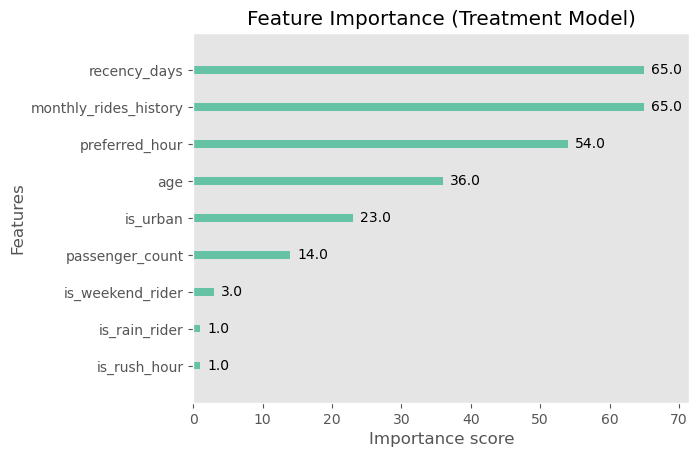

In [9]:
import xgboost as xgb

plt.figure(figsize=(10, 5))
xgb.plot_importance(model_1, importance_type='weight', max_num_features=10, title='Feature Importance (Treatment Model)', grid=False)
plt.show()


## 8. Chân dung Khách hàng Mục tiêu (Customer Profiling)
So sánh đặc điểm của nhóm Top 20% (Nên tặng Voucher) với nhóm còn lại (Không nên tặng).

In [10]:
df_sorted['is_top_20'] = np.where(df_sorted.index < int(total_users * 0.2), 'Top 20% (Target)', 'Bottom 80% (Ignore)')

# Ghép features gốc vào để phân tích
df_profile = df_sorted.join(X_test.drop(columns=['monthly_rides_history']).reset_index(drop=True))

profile_summary = df_profile.groupby('is_top_20')[['age', 'monthly_rides_history', 'recency_days', 'user_avg_fare']].mean().round(2)
print("--- CHÂN DUNG KHÁCH HÀNG (TOP 20% vs 80%) ---")
display(profile_summary)


--- CHÂN DUNG KHÁCH HÀNG (TOP 20% vs 80%) ---


,age,monthly_rides_history,recency_days,user_avg_fare
is_top_20,,,,
Bottom 80% (Ignore),34.55,2.83,11.71,29.16
Top 20% (Target),34.93,3.59,12.18,27.36
